Upload a grayscale image


Saving jelly.jpg to jelly (1).jpg


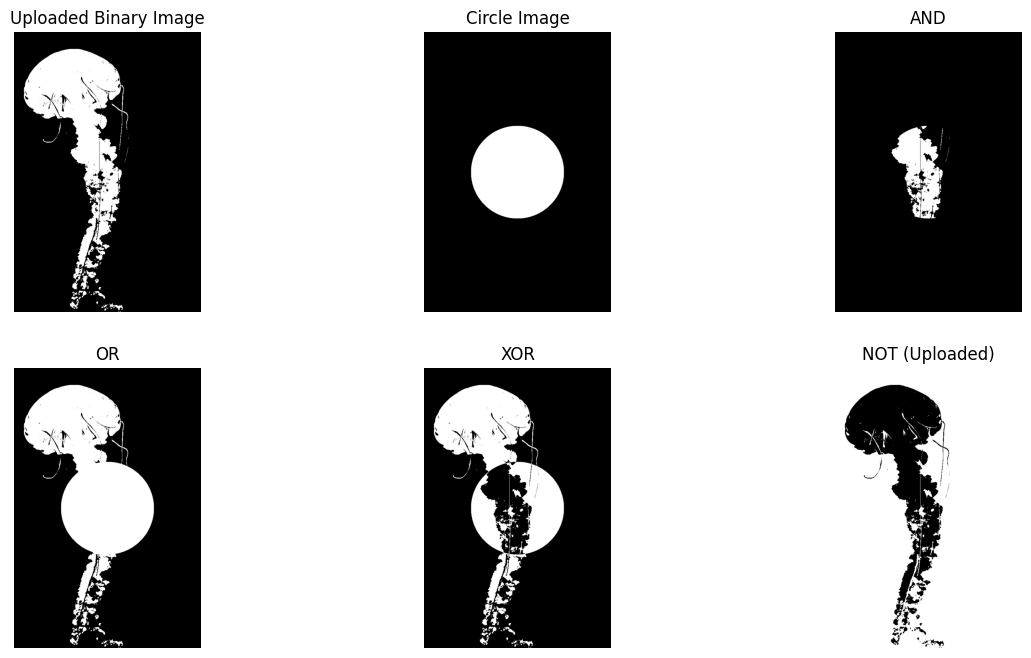

In [3]:

import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# Step 1: Upload one image
print("Upload a grayscale image")
uploaded = files.upload()

img_name = list(uploaded.keys())[0]

# Step 2: Read image in grayscale
img1 = cv2.imread(img_name, 0)

if img1 is None:
    print("Error loading image")
else:
    # Step 3: Convert to binary
    _, bin1 = cv2.threshold(img1, 50, 255, cv2.THRESH_BINARY)

    # Step 4: Create a blank image same size
    height, width = bin1.shape
    circle_img = np.zeros((height, width), dtype=np.uint8)

    # Step 5: Draw white filled circle at center
    center = (width // 2, height // 2)
    radius = min(height, width) // 4
    cv2.circle(circle_img, center, radius, 255, -1)

    # Step 6: Perform Logical Operations
    and_img = cv2.bitwise_and(bin1, circle_img)
    or_img  = cv2.bitwise_or(bin1, circle_img)
    xor_img = cv2.bitwise_xor(bin1, circle_img)
    not_img = cv2.bitwise_not(bin1)

    # Step 7: Display results
    titles = ['Uploaded Binary Image', 'Circle Image',
              'AND', 'OR', 'XOR', 'NOT (Uploaded)']
    images = [bin1, circle_img, and_img, or_img, xor_img, not_img]

    plt.figure(figsize=(15,8))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()
